![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [4]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
----------------------------------------
✓ numpy 2.3.2
✓ pandas 2.3.2
✓ matplotlib 3.10.6
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [5]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- **Respuesta 1:** En nuestro caso, la latencia es entonces el tiempo que tardaría mi máquina personal, en este caso, en acceder al disco duro para la lectura y escritura del archivo que se va a crear más adelante.

- **Respuesta 2:** En nuestro caso, el throughput sería la velocidad que persistirá durante el proceso de acceso y lectura en el disco a través del archivo de pruebas.

- **Respuesta 3:** Esto se debe entonces a que, como M representa los accesos no contiguos en disco, si este fuera mayor, no leería todos los bloques continuamente, sino que podría llegar a saltarse alguno al no poder acceder de uno en uno, por lo que ya no lo consideraríamos como un acceso secuencial.

- **Respuesta 4:** Contrario al anterior, al ser mayor a 1, ese puede acceder a bloques que estén separados entre sí; en este caso depende de M el número de bloques que salta de uno a otro, pudiendo entonces acceder a distintos bloques en menor tiempo, pero sin leerlos todos.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [6]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 1500

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 1500
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- **Respuesta 1:** El archivo supera el tamaño de la caché inicialmente.

- **Respuesta 2:** Yo, en lo personal, esperaría que tuviera un mejor rendimiento un tamaño de 256, debido a que, al ser un tamaño más grande, el acceso podría tender a ser más separado de un bloque a otro, cubriendo una mayor parte del acceso.

- **Respuesta 3:** El laboratorio está ejecutándose en entorno local (se está utilizando Visual Studio Code).


### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [7]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

RESET = False. No se eliminó ningún archivo.
Cambie RESET = True si desea repetir el experimento con nuevos parámetros.


## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [8]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

Creando archivo de 1500 MB...
Archivo creado correctamente.
Tamaño final del archivo (bytes): 1572864000


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- **Respuesta 1:** En este contexto, el archivo simularía una especie de disco duro con la función de lectura de archivos dentro de sí mismo.

- **Respuesta 2:** Porque al ser un archivo que contiene más registros, podemos simular de mejor manera un entorno cotidiano (un disco duro actual) y así ver reflejado el acceso a disco.

- **Respuesta 3:** Si el archivo fuera demasiado pequeño, probablemente el sistema operativo lo cargue completamente en la caché. Esto haría que los accesos no se realicen realmente al disco, sino a memoria RAM, que es mucho más rápida.

## 5. Funciones auxiliares de medición

In [21]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [23]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 1.6815 s, throughput: 892.04 MiB/s
Aleatorio  -> tiempo: 0.0212 s, throughput: 735.94 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.4801 s, throughput: 3124.37 MiB/s
Aleatorio  -> tiempo: 0.0307 s, throughput: 2038.13 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.3236 s, throughput: 4635.65 MiB/s
Aleatorio  -> tiempo: 0.0641 s, throughput: 3899.70 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.2746 s, throughput: 5463.16 MiB/s
Aleatorio  -> tiempo: 0.1947 s, throughput: 5135.70 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,1572864000,384000,1.681547,892.035780,4.0
1,Aleatorio,4096,16384000,4000,0.021231,735.938280,4.0
2,Secuencial,16384,1572864000,96000,0.480097,3124.367966,16.0
3,Aleatorio,16384,65536000,4000,0.030665,2038.127662,16.0
4,Secuencial,65536,1572864000,24000,0.323579,4635.647387,64.0
5,Aleatorio,65536,262144000,4000,0.064108,3899.699723,64.0
6,Secuencial,262144,1572864000,6000,0.274566,5463.157377,256.0
7,Aleatorio,262144,1048576000,4000,0.194716,5135.695342,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

Respondiendo a las preguntas anteriores, tenemos entonces que, por bloque en términos de tiempo, el acceso aleatorio fue el más rápido en todos los casos; por ej., en el caso del bloque de 256.00 KB, que fue el caso con los tiempos más parecidos, con 0.08 s de diferencia, donde el acceso aleatorio fue un poco más rápido en términos de tiempo, pero en términos de rendimiento (throughput) en todo momento fue el acceso secuencial, siendo entonces, por ej., en el bloque de 256.00 KB, su rendimiento de 5463.16 MiB/s, mientras que en el acceso aleatorio fue de 5135.70 MiB/s. Con respecto al throughput, tenemos que fue cambiando de tamaño respecto al bloque anterior; por ej., vemos una diferencia bastante notoria entre el primer bloque (4.00 KB) y el segundo (16.00 KB), siendo entonces de 892.04 MiB/s para el acceso secuencial en el primer bloque y de 3124.37 MiB/s de acceso secuencial en el segundo bloque. Finalmente, tenemos que el caso con mayor diferencia entre patrones de acceso sería cuando el bloque fue de 256.00 kB, al menos en tiempo de throughput, en donde el acceso secuencial tuvo un throughput de 5463.16 MiB/s y el acceso aleatorio un throughput de 3549.57 MiB/s, en comparación, por ejemplo, con su bloque anterior de 64.00 kB, donde el acceso secuencial tuvo un throughput de 4635.65 MiB/s y el acceso aleatorio tuvo un throughput de 3899.70 MiB/s. Comparándolos, vemos que el de 256 kB es ligeramente más lento, ya que sus tiempos varían, siendo más rápido en el bloque de 64.00 kB y más eficiente en comparación al de 64 kB.

## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [25]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado:
- Latencia asumida:
- Throughput asumido:

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

In [26]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.292979,5119.825243
1,Aleatorio,4096,4.0,0.043052,362.935239
2,Secuencial,16384,16.0,0.292979,5119.825243
3,Aleatorio,16384,16.0,0.052207,1197.156753
4,Secuencial,65536,64.0,0.292979,5119.825243
5,Aleatorio,65536,64.0,0.088828,2814.423923
6,Secuencial,262144,256.0,0.292979,5119.825243
7,Aleatorio,262144,256.0,0.235313,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [27]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,1572864000,384000,1.681547,892.035780,4.0,0.292979,5119.825243,5.739484,0.174232
1,Aleatorio,4096,16384000,4000,0.021231,735.938280,4.0,0.043052,362.935239,0.493160,2.027740
2,Secuencial,16384,1572864000,96000,0.480097,3124.367966,16.0,0.292979,5119.825243,1.638676,0.610249
3,Aleatorio,16384,65536000,4000,0.030665,2038.127662,16.0,0.052207,1197.156753,0.587381,1.702474
4,Secuencial,65536,1572864000,24000,0.323579,4635.647387,64.0,0.292979,5119.825243,1.104447,0.905431
5,Aleatorio,65536,262144000,4000,0.064108,3899.699723,64.0,0.088828,2814.423923,0.721703,1.385612
6,Secuencial,262144,1572864000,6000,0.274566,5463.157377,256.0,0.292979,5119.825243,0.937155,1.067059
7,Aleatorio,262144,1048576000,4000,0.194716,5135.695342,256.0,0.235313,4249.667995,0.827477,1.208493


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta
Los tiempos van variando dependiendo del bloque donde nos ubiquemos en el caso del acceso secuencial. Por ej., al ubicarnos en el bloque de 256 KB, el acceso secuencial empírico tiene un tiempo de 0.274566 s, mientras que el teórico tiene un tiempo de 0.292979 s, que es ligeramente mayor; pero si, por ejemplo, nos ubicamos en el bloque de 64 KB, tenemos que el acceso secuencial empírico tiene un tiempo de 0.323579 s, mientras que en el teórico tenemos un tiempo de 0.292979, que es ligeramente menor. Entonces, mientras más grande sea el bloque, más rápido en términos de tiempo del análisis empírico. Yo diría que el patrón de acceso secuencial en el bloque de 256 KB es el que más se le aproxima, tanto en términos de tiempo como de throughput. Finalmente, hablando de qué factores pueden estar afectando para que los resultados sean diferentes, podría deberse, primero que nada, a la cantidad de caché que reserva la RAM en mi máquina, que va variando bastante; por ejemplo, cuando escribo esto, el caché está en 2,2GB, por lo que ese puede ser un factor notable. Y el otro factor podría ser también la carga de procesos que tenía el sistema cuando realicé las pruebas, ya que no se consumen muchos recursos en reposo; entonces, esto pudo haber hecho que mi máquina haya reservado la mayor parte de recursos cuando se corrió la prueba.


## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [28]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\yecar\Desktop\Universidad\Semestre 7 (2026-1)\Estructura de datos y Lab\Laboratorios Estructuras de datos Y Lab's\lab3-IO_performance-JuanFernandoMonaCano\Images


Guardada: fig_throughput.png


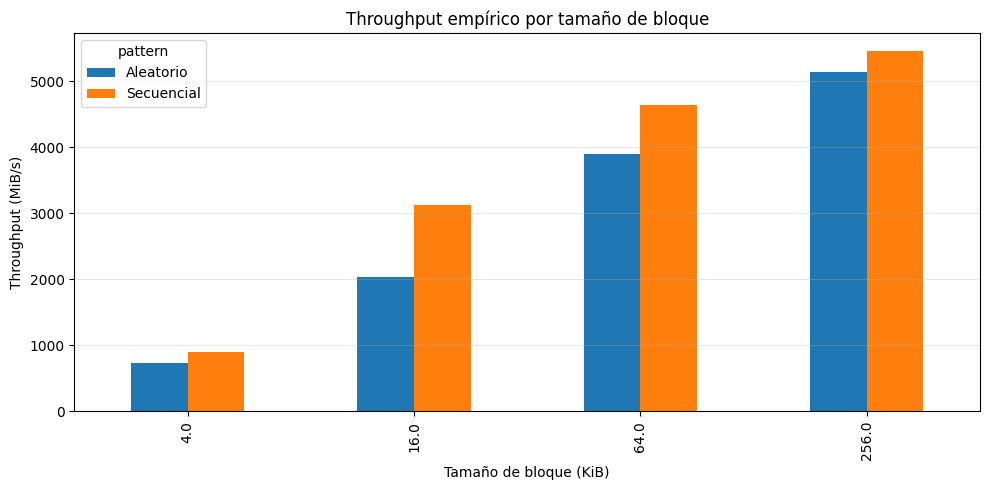

In [36]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta
En todos los casos podemos observar que las barras más altas son las del acceso secuencial; entonces, esto significa que el acceso secuencial es más eficiente que el acceso aleatorio en términos de rendimiento, es decir, que podría buscar una mayor cantidad de información sin usar una cantidad de recursos absurda. Si miramos, por ejemplo, el bloque de 256.00 KB, nos daremos cuenta de que el acceso secuencial tiene un throughput de aproximadamente 5500 MiB/s, mientras que el acceso aleatorio tiene un aproximado de 5100 MiB/s en el mismo bloque, por lo que concluyo que el patrón de acceso secuencial aprovecha mejor la lectura de los bloques debido al mayor rendimiento que presenta durante la gráfica.

Guardada: fig_tiempo_empirico.png


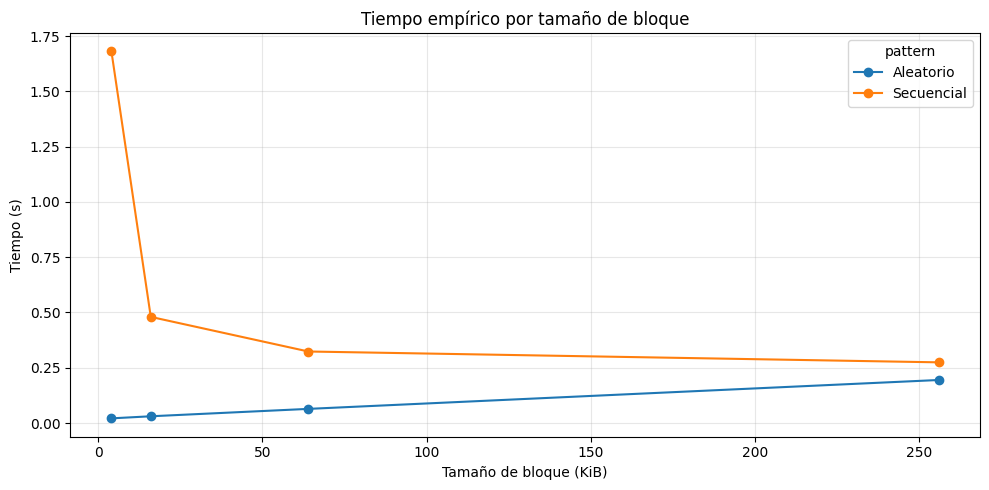

In [31]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

Si vemos la anterior gráfica, podemos darnos cuenta de que el acceso aleatorio es muy poco variable en cada bloque que pasa respecto al tiempo; por ejemplo, si vemos el bloque de 4.00 kb comparado con el de 16.00kb, es mínima la diferencia en tiempo que hay entre ambos, e igual con el de 64.00kb, y aunque el de 256.00 kb tiene un tiempo ligeramente mayor, no es una diferencia significativa respecto a los anteriores. Lo que sí es que, a medida que crece el bloque, también aumenta el tiempo linealmente. Si lo comparamos con el patrón de acceso secuencial, podemos ver una diferencia bastante considerable a medida que pasan los bloques, ya que casi empezamos desde los 2 segundos en el bloque de 4 kb y luego este se estabiliza desde los 64 kb hasta los 256 kb, pero a diferencia del aleatorio, que es linealmente constante y va aumentando su tiempo, el secuencial es más bien lo contrario y su tiempo va disminuyendo con el tiempo.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


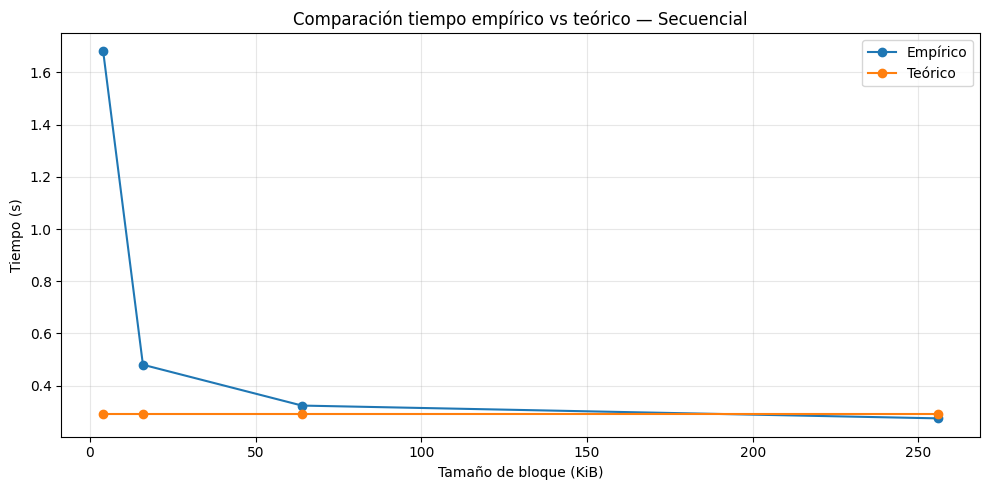

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


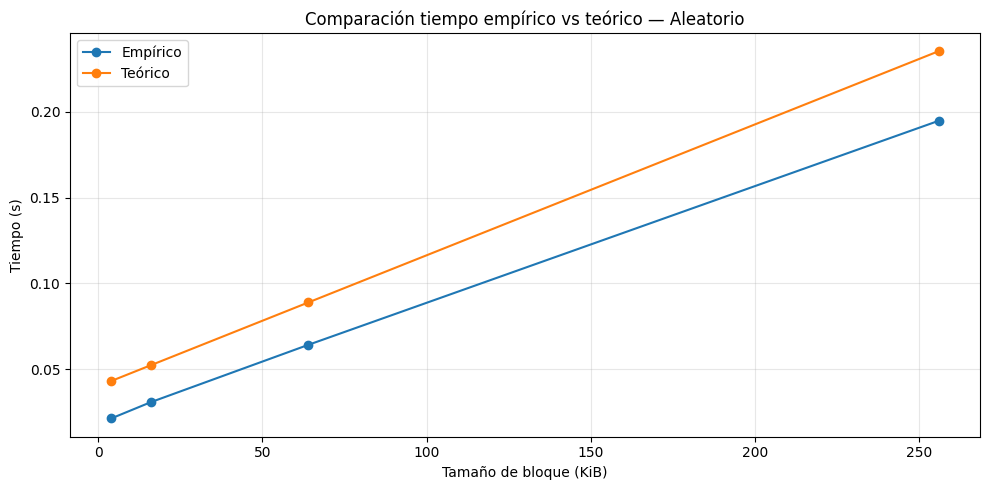

In [32]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta
Solo en el caso del acceso aleatorio las curvas tienen una tendencia similar y unos tiempos aproximadamente similares, pero el caso contrario sería el caso del acceso secuencial, donde el modelo empírico, que al empezar son completamente diferentes en tiempo, aunque a medida que se avanza por los bloques los tiempos tienden a ser similares. En el caso del acceso secuencial, las gráficas se separan más justo al inicio, en el primer bloque, y en el caso del acceso aleatorio, se separan en todo momento y de manera casi constante, pero se separan de una manera un poco más pronunciada en el último bloque. El modelo en general sobreestima el tiempo real, especialmente en el acceso aleatorio, donde los valores de tiempo teóricos son mayores que los empíricos, donde una posible razón podría ser que el modelo no tiene en cuenta efectos como la caché del sistema operativo, que reduce los tiempos reales al evitar accesos directos al disco.

Guardada: fig_speedup.png


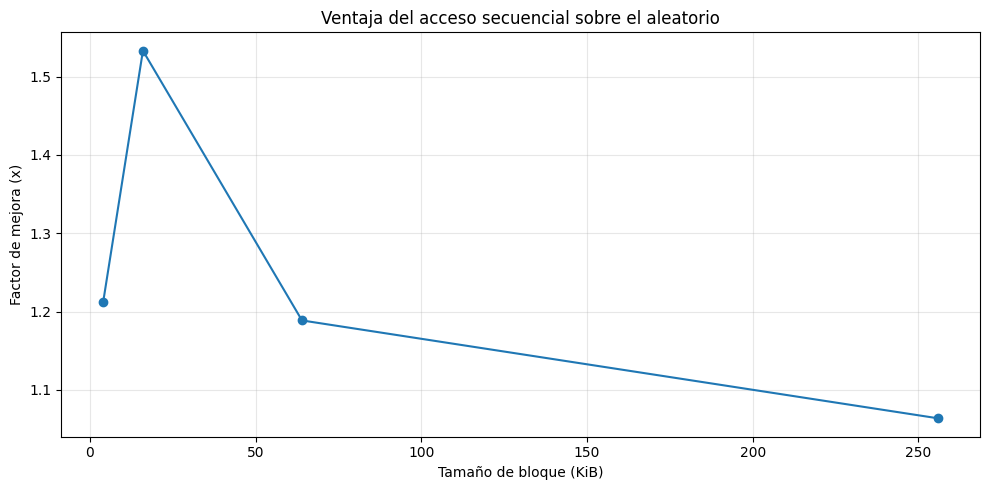

In [33]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta
El mayor factor de mejora que se observa en la gráfica es de $\approx 1.6$ en el bloque de 16, siguiendo entonces una mejora de $\approx 1.2$ en el bloque de 4 kb y luego una mejora de $\approx 1.19$ en el bloque de 64; esta ventaja es variable dependiendo del tamaño del bloque, ya que a partir del bloque de 64 kb el factor de mejora disminuye casi por completo, pero no es 0, por lo que sigue habiendo una mejora del acceso secuencial sobre el aleatorio. Esto implica que, en el diseño de software, es preferible organizar los datos y accesos de forma secuencial, es decir, uno tras otro, ya que ofrece mejor rendimiento que el acceso aleatorio, especialmente con ciertos tamaños de bloque. Además, sugiere que elegir adecuadamente el tamaño de bloque puede influir en el rendimiento, por lo que se deben evitar accesos dispersos y aprovechar la localidad de los datos.

## 10. Resumen automático de resultados

In [34]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,1.681547,0.021231,892.035780,735.938280,1.212107
1,16.0,0.480097,0.030665,3124.367966,2038.127662,1.532960
2,64.0,0.323579,0.064108,4635.647387,3899.699723,1.188719
3,256.0,0.274566,0.194716,5463.157377,5135.695342,1.063762


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

La información se almacena en el disco organizándose en bloques, donde el sistema de archivos traduce estos archivos lógicos en direcciones de hardware específicas. Esto es crucial porque el rendimiento depende de la eficiencia con la que el controlador localiza y recupera estos bloques. En el acceso secuencial, el sistema lee los datos de forma contigua, mientras que en el aleatorio debe buscar direcciones dispersas, generando latencia. Incluso en los SSD, aunque no hay piezas móviles, el acceso aleatorio es más lento debido a la sobrecarga del controlador. En cuanto a qué tan preciso fue el modelo teórico respecto al modelo empírico, tenemos que al principio fue bastante flojo, pero a medida que los bloques eran más grandes, este modelo teórico iba aproximándose al modelo empírico (máquina personal). Por ejemplo, al principio, cuando los bloques eran de 4.00 KB, teníamos en el modelo empírico un rendimiento de 892.035780 MiB/s y un rendimiento de 735.938280 MiB/s para el acceso secuencial y aleatorio, respectivamente, mientras que en el modelo teórico ya teníamos un rendimiento de 5119.825243 MiB/s y de 362.935239 MiB/s para el acceso secuencial y aleatorio, respectivamente, siendo entonces en el secuencial donde observamos una diferencia enorme. Entonces, yo en lo personal, a la hora de diseñar un sistema, estaría atento a qué tipo de patrón de acceso elegir cuando quiera acceder a alguna información, ya que cada patrón es útil para su respectivo caso. Por ejemplo, para leer muchos datos pequeños en poco tiempo, preferiría usar un acceso aleatorio y para datos más grandes, preferiría elegir el acceso secuencial.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.